**# RoadRisk-Public-Spending-Brazil**
 In this project, I will build a **machine learning model to predict accident volumes and the associated public spending impact on federal highways in Minas Gerais (MG).** It involves supervised learning to forecast monthly patterns for 2026 and **estimate the financial burden of traffic accidents on the state's public resources.**

 I will use the following **pipeline** based on the **CRISP-DM framework:**

**1. Define the business problem.**

**2. Collect the data and get a general overview of it.**

**3. Split the data into train and test sets.**

**4. Explore the data (exploratory data analysis).**

**5. Feature engineering, data cleaning, and preprocessing.**

**6. Model training, comparison, feature selection, and tuning.**

**7. Final production model testing and evaluation.**

**8. Conclude and interpret the model results.**
 
**9. Deploy.**

 In **this notebook**, I will perform exploratory data analysis (EDA), covering steps 1 to 4 of the pipeline above. The main objective here is to uncover insights regarding temporal (seasonality), geographic (highways/segments), and contextual (accident causes) patterns within Minas Gerais. Thus, even before building a model, it will be possible to support stakeholders—such as the State Government, PRF, and SAMU MG—with data-driven profiles for enforcement prioritization and emergency readiness planning. Furthermore, I will approach these steps in detail below, explaining the rationale behind each decision.

# 1 — BUSINESS UNDERSTANDING
## 1. Business Problem
The state of Minas Gerais holds one of the largest and most complex federal highway networks in Brazil, resulting in a critical volume of accidents that strains public funds and emergency services (SAMU and PRF). Currently, the allocation of speed cameras, patrol vehicles, and rescue teams is mostly reactive or based on simple historical averages, without considering seasonality and the direct financial impact of each incident. This lack of predictability prevents the state government and federal agencies from optimizing safety and infrastructure investments, leading to inefficient spending and the loss of lives that could be prevented through data-driven preventive interventions.

## 1.1 What is the context?
The scenario involves road safety management and public health in a strategic territory for Brazilian logistics. The project aims to integrate police occurrence data with financial and predictive impact models to transform highway management into an evidence-based operation.

Severity Rate per Segment: A metric that weights accidents by the number of victims and severity in specific stretches, allowing the identification of where the risk to life is highest, regardless of the total collision volume.

Estimated Operational Cost (EOC): Projected value of public spending (SAMU, road clearing, forensics) per accident type, serving as a basis to justify investments in electronic surveillance.

Electronic Surveillance ROI: The relationship between the implementation cost of speed cameras (CAPEX/OPEX) and the expected reduction in accident spending plus projected revenue, aiming for the fiscal balance of the measure.

## 1.2 Which are the project objectives?
2026 Seasonality Forecast: Generate a monthly forecast of accident volumes for the year 2026 with an accuracy target between 90% and 95%, allowing for advanced planning of work shifts and SAMU resources.

Cost-Benefit Modeling for Speed Cameras: Quantify implementation costs and the expectation of revenue and public savings for new surveillance points.

Impact Simulation of Measures: Create scenarios that demonstrate the potential reduction in accidents and public spending if specific measures (speed cameras, increased patrolling) are applied to identified hotspots.

## 1.3 Which are the project benefits?
Optimization of Public Resources: Precise allocation of funds to stretches where every real invested in prevention generates the greatest savings in hospital and operational costs.

Increased SAMU Readiness: Reduction in response time to serious incidents through strategic positioning of teams based on monthly forecasts.

Transparent and Justifiable Decisions: Provide stakeholders (MG Government and PRF) with technical grounding for speed camera installation, balancing safety and revenue.

Mortality Reduction: Direct decrease in deaths and serious injuries through electronic surveillance in locations with high accident rates due to speeding.

## 1.4 Conclusion — Output Strategy
The final delivery based on predictive models and scenario simulators is superior to static reports because it allows the public manager to interact with the data (e.g., "What if we install 10 speed cameras on BR-381?"). While descriptive analysis only shows the past, a Machine Learning model with 90%+ accuracy offers a budgetary and operational planning tool for 2026, directly connecting the cost of safety with the benefit of preserving lives and public funds.

## NOTEBOOK VISUAL CONFIGURATION

In [ ]:
# ============================================================
# RoadRisk-Public-Spending-Brazil — Visual Configuration
# ============================================================

# Data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os

# Global visualization settings
%matplotlib inline

mpl.style.use('ggplot')

mpl.rcParams['axes.facecolor']  = 'white'     # White background for clarity in reports
mpl.rcParams['axes.linewidth']  = 1.2           # Slightly highlighted border
mpl.rcParams['xtick.color']     = '#2c3e50'    # Dark gray ticks for readability
mpl.rcParams['ytick.color']     = '#2c3e50'
mpl.rcParams['grid.color']      = '#ecf0f1'    # Soft grid to avoid clutter
mpl.rcParams['figure.dpi']      = 150          # High resolution for presentations
mpl.rcParams['axes.grid']       = True         # Always show grid
mpl.rcParams['font.size']       = 10           # Base font size

# Project Color Palette — Focus on Safety and Alert
# Justification: 
# - Deep Blue (#001F3F): Represents government authority and stability (PRF/State).
# - Orange Tones: Represent alerts, traffic signaling, and urgency (Radar/SAMU).
# - Gray (#95a5a6): Used for secondary or historical data.
color_palette = [
    '#001F3F', # Navy Blue (Primary - Institutional)
    "#CA6E1D", # Vibrant Orange (Highlight - Speed Cameras/Alerts)
    "#C92E26", # Soft Red (Emergency - Serious Accidents)
    "#F8B34C", # Pastel Orange (Secondary data/Averages)
    "#2C75B9", # Teal (Cost comparisons)
    '#95a5a6'  # Neutral Gray (Historical context)
]

# Applying as the default seaborn palette
sns.set_palette(sns.color_palette(color_palette))

# Display for visual validation
print("RoadRisk color palette successfully defined!")
sns.color_palette(color_palette)

RoadRisk color palette successfully defined!


[(0.0, 0.12156862745098039, 0.24705882352941178),
 (0.792156862745098, 0.43137254901960786, 0.11372549019607843),
 (0.788235294117647, 0.1803921568627451, 0.14901960784313725),
 (0.9725490196078431, 0.7019607843137254, 0.2980392156862745),
 (0.17254901960784313, 0.4588235294117647, 0.7254901960784313),
 (0.5843137254901961, 0.6470588235294118, 0.6509803921568628)]

2. DATA UNDERSTANDING

2.1 Coleta e Visão Geral
Objetivo: Carregar os dados processados e auditar a integridade técnica da filtragem realizada no ETL. É o momento de garantir que os dados de Minas Gerais estão completos, consistentes e prontos para análise.

In [ ]:
# 1. Carregamento e Inspeção Inicial (Checkpoint de Segurança)
df_occ = pd.read_parquet("../data/processed/occ_mg_master.parquet")
df_occ['data_inversa'] = pd.to_datetime(df_occ['data_inversa'])

print("--- Prévia dos Dados Processados (MG) ---")
# Exibe as 5 primeiras linhas para validar colunas e valores
display(df_occ.head()) 

# 2. Preparação dos dados para o gráfico
# Contagem de acidentes por ano
annual_counts = df_occ.groupby('year_reference').size()

# 3. Plotagem profissional com a identidade visual RoadRisk
plt.figure(figsize=(12, 6))

# Usando o Navy Blue (Primary) da nossa paleta
ax = annual_counts.plot(kind='bar', color=color_palette[0], edgecolor='white', linewidth=1.2)

# Refinamento Estético
plt.title("Volume Total de Acidentes em MG por Ano (2017-2025)", 
          fontsize=14, pad=20, fontweight='bold', color=color_palette[0])
plt.ylabel("Quantidade de Acidentes", fontsize=12, labelpad=10)
plt.xlabel("Ano de Referência", fontsize=12, labelpad=10)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Adicionando Rótulos de Dados (Data Labels)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=10, fontweight='bold', color=color_palette[0])

# Finalização do Layout
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# 1. Carregamento dos dados
df_occ = pd.read_parquet("../data/processed/occ_mg_master.parquet")
df_occ['data_inversa'] = pd.to_datetime(df_occ['data_inversa'])

# 2. Inspeção visual rápida
print(f"Dataset carregado com {df_occ.shape[0]} linhas.")
df_occ.head()

Dataset carregado com 83409 linhas.


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,year_reference
0,123.0,2017-01-01,domingo,11:50:00,MG,262,483.1,BOM DESPACHO,Condutor Dormindo,Colisão lateral,...,2,1,0,3,-19.785618,-45.309561,SPRF-MG,DEL08-MG,UOP03-DEL08-MG,2017
1,185.0,2017-01-01,domingo,16:30:00,MG,381,672.8,PERDOES,Não guardar distância de segurança,Derramamento de carga,...,0,0,1,1,-21.094537,-45.075492,SPRF-MG,DEL04-MG,UOP02-DEL04-MG,2017
2,228.0,2017-01-01,domingo,18:20:00,MG,116,702.8,MURIAE,Desobediência às normas de trânsito pelo condutor,Colisão transversal,...,2,1,0,3,-21.124707,-42.381322,SPRF-MG,DEL07-MG,UOP02-DEL07-MG,2017
3,351.0,2017-01-02,segunda-feira,04:57:00,MG,381,567.1,ITAGUARA,Condutor Dormindo,Colisão traseira,...,47,0,0,2,-20.404118,-44.516957,SPRF-MG,DEL04-MG,UOP03-DEL04-MG,2017
4,356.0,2017-01-02,segunda-feira,06:20:00,MG,40,520.5,CONTAGEM,Falta de Atenção à Condução,Colisão traseira,...,1,0,3,2,-19.852095,-44.072701,SPRF-MG,DEL01-MG,UOP03-DEL01-MG,2017


2.2 Dicionário de Dados (Modelo Técnico)
Objetivo: Estabelecer uma referência técnica rigorosa para cada variável, classificando-as entre tipos numéricos e categóricos para orientar o pré-processamento e a modelagem de 2026.

Dicionário de Dados (Ocorrências):

id: Identificador único da ocorrência. Chave primária do acidente. Categorical nominal.

data_inversa: Data em que ocorreu o acidente. Numerical discrete (Série Temporal).

dia_semana: Dia da semana do registro. Categorical ordinal.

horario: Horário aproximado do acidente. Categorical nominal (Temporal).

uf: Unidade Federativa (Filtrado para 'MG'). Categorical nominal.

br: Número da rodovia federal (ex: 381, 040). Categorical nominal.

km: Marco quilométrico da rodovia onde ocorreu o fato. Numerical continuous.

municipio: Nome do município mineiro. Categorical nominal.

causa_principal: Fator determinante do acidente (Sim/Não para causa principal). Categorical nominal.

ilesos: Quantidade de pessoas sem ferimentos no acidente. Numerical discrete.

feridos_leves: Quantidade de vítimas com lesões leves. Numerical discrete.

feridos_graves: Quantidade de vítimas com lesões severas. Numerical discrete.

mortos: Quantidade de fatalidades registradas. Numerical discrete.

latitude: Coordenada geográfica de latitude. Numerical continuous.

longitude: Coordenada geográfica de longitude. Numerical continuous.

regional: Superintendência Regional da PRF responsável. Categorical nominal.

delegacia: Delegacia da PRF que atendeu a ocorrência. Categorical nominal.

uop: Unidade Operacional de Polícia vinculada. Categorical nominal.

year_reference: Ano de referência da série histórica (2017-2025). Numerical discrete.

2.2.1 Verificação de Tipos e Consistência (Código)
Esta célula valida se os tipos inferidos pelo Python estão alinhados com as definições do dicionário acima.

In [ ]:
# Mapeamento de papéis para facilitar a análise bivariada posterior
features_categoricas = ['dia_semana', 'br', 'municipio', 'causa_principal', 'regional']
features_numericas = ['km', 'latitude', 'longitude', 'year_reference']
targets_gastos = ['ilesos', 'feridos_leves', 'feridos_graves', 'mortos']

# Auditoria de tipos de dados (dtypes)
print(f"--- Auditoria de Tipos: Dataset Ocorrências (MG) ---")
resumo_tipos = pd.DataFrame({
    'Dtype Atual': df_occ.dtypes,
    'Valores Únicos': df_occ.nunique(),
    'Exemplo': df_occ.iloc[0]
})

display(resumo_tipos)

--- Auditoria de Tipos: Dataset Ocorrências (MG) ---


,Dtype Atual,Valores Únicos,Exemplo
id,float64,83409,123.0
data_inversa,datetime64[us],3287,2017-01-01 00:00:00
dia_semana,str,7,domingo
horario,str,1352,11:50:00
uf,str,1,MG
br,int64,22,262
km,float64,8893,483.1
municipio,str,255,BOM DESPACHO
causa_acidente,str,90,Condutor Dormindo
tipo_acidente,str,21,Colisão lateral


Insights e Métricas de Negócio (Passo 2.2)

Identificação de Targets: Variáveis como mortos e feridos_graves são classificadas como Numerical discrete. Elas serão as variáveis dependentes (alvos) para o cálculo do Impacto Financeiro, uma vez que cada "unidade" de vítima grave possui um custo hospitalar e operacional tabelado pelo Estado.

Natureza das Variáveis de Localização: A variável km é Numerical continuous. Isso é essencial para que possamos realizar análises de regressão espacial e identificar trechos específicos onde a redução de velocidade é necessária.

Tratamento de Categorias: Variáveis como br e municipio são Categorical nominal. Devido à alta cardinalidade (muitos valores diferentes), precisaremos de estratégias de encoding robustas na Etapa 3 (Data Preparation) para que o modelo de 2026 consiga processá-las sem perda de informação geográfica.

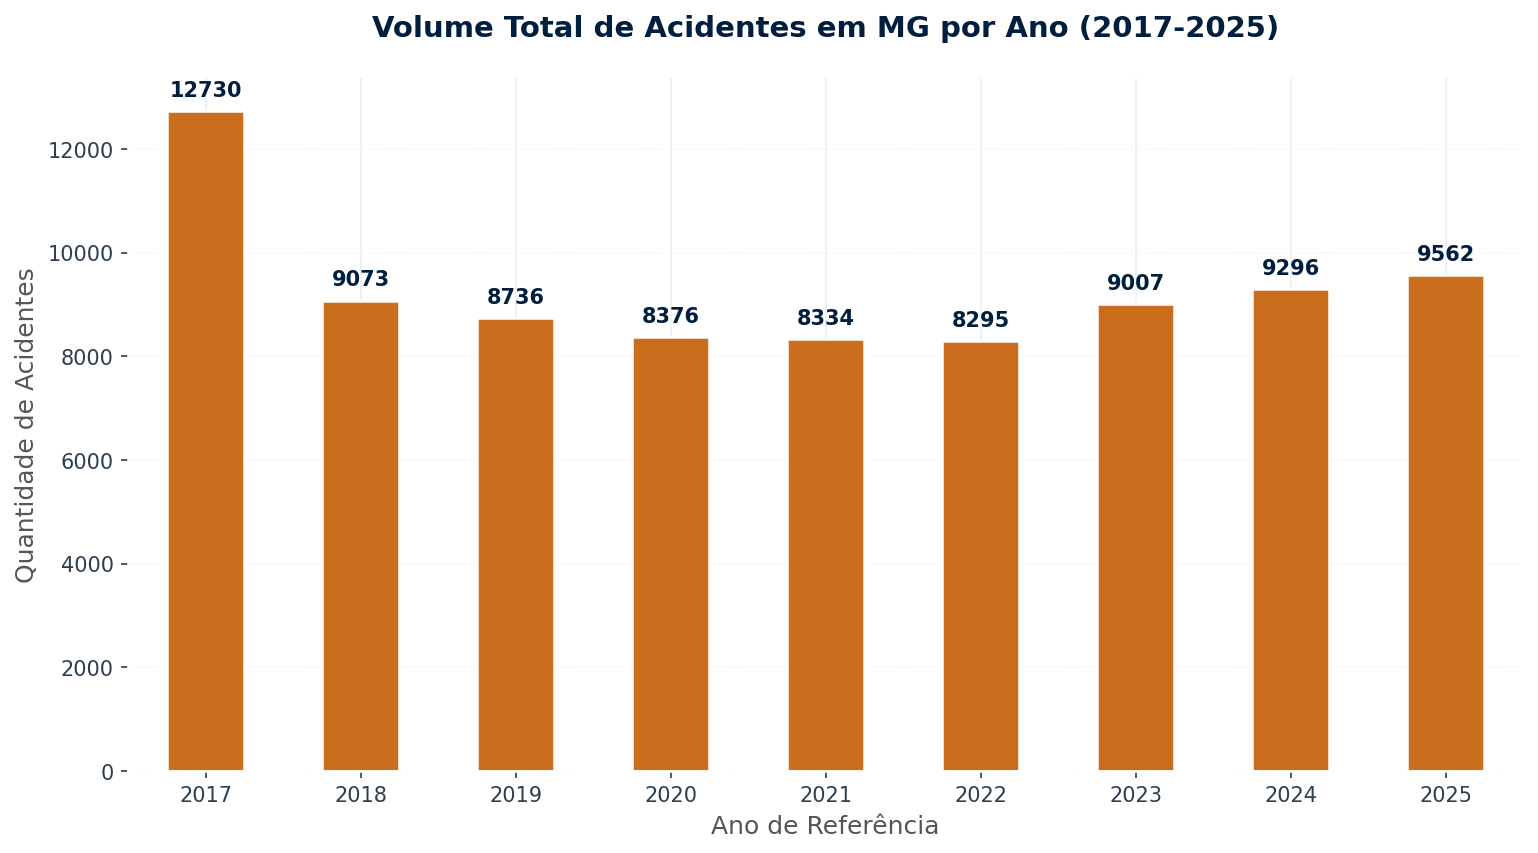

In [ ]:
# Contagem e Plotagem
annual_counts = df_occ.groupby('year_reference').size()

plt.figure(figsize=(12, 6))
ax = annual_counts.plot(kind='bar', color=color_palette[1], edgecolor='white', linewidth=1.2)

# Estética RoadRisk
plt.title("Volume Total de Acidentes em MG por Ano (2017-2025)", 
          fontsize=14, pad=20, fontweight='bold', color=color_palette[0])
plt.ylabel("Quantidade de Acidentes")
plt.xlabel("Ano de Referência")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Rótulos de dados
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                fontsize=10, fontweight='bold', color=color_palette[0])

sns.despine()
plt.show()

Insights e Métricas de Negócio (Passo 2.1.1)

Padrão de Estabilidade: O gráfico de barras permite comparar visualmente se o volume de acidentes em Minas Gerais é estável ou se apresenta tendências de queda/alta acentuadas. Isso é fundamental para calibrar a expectativa da meta de acurácia de $90\%-95\%$ para 2026.

Identificação de Outliers Temporais: Se houver anos com volumes drasticamente menores (como o início da pandemia em 2020), o gestor público (Stakeholder) saberá que esse dado precisa de um peso diferente no modelo preditivo, pois não reflete o fluxo normal de veículos.

Fundação para o EOC: O volume total anual é o multiplicador base para o Custo Operacional Estimado (EOC). Com esses números validados, podemos começar a projetar o impacto financeiro total que os acidentes representam para o Estado de MG.

2.1.2 Alinhamento de Chaves e Integridade
Objetivo: Verificar a integridade referencial entre os datasets de Ocorrências (onde estão a BR e o KM) e Pessoas (onde estão os dados de gravidade e custos). Sem um alinhamento de 100\%, o cálculo do Custo Operacional Estimado (EOC) por trecho rodoviário será impreciso.

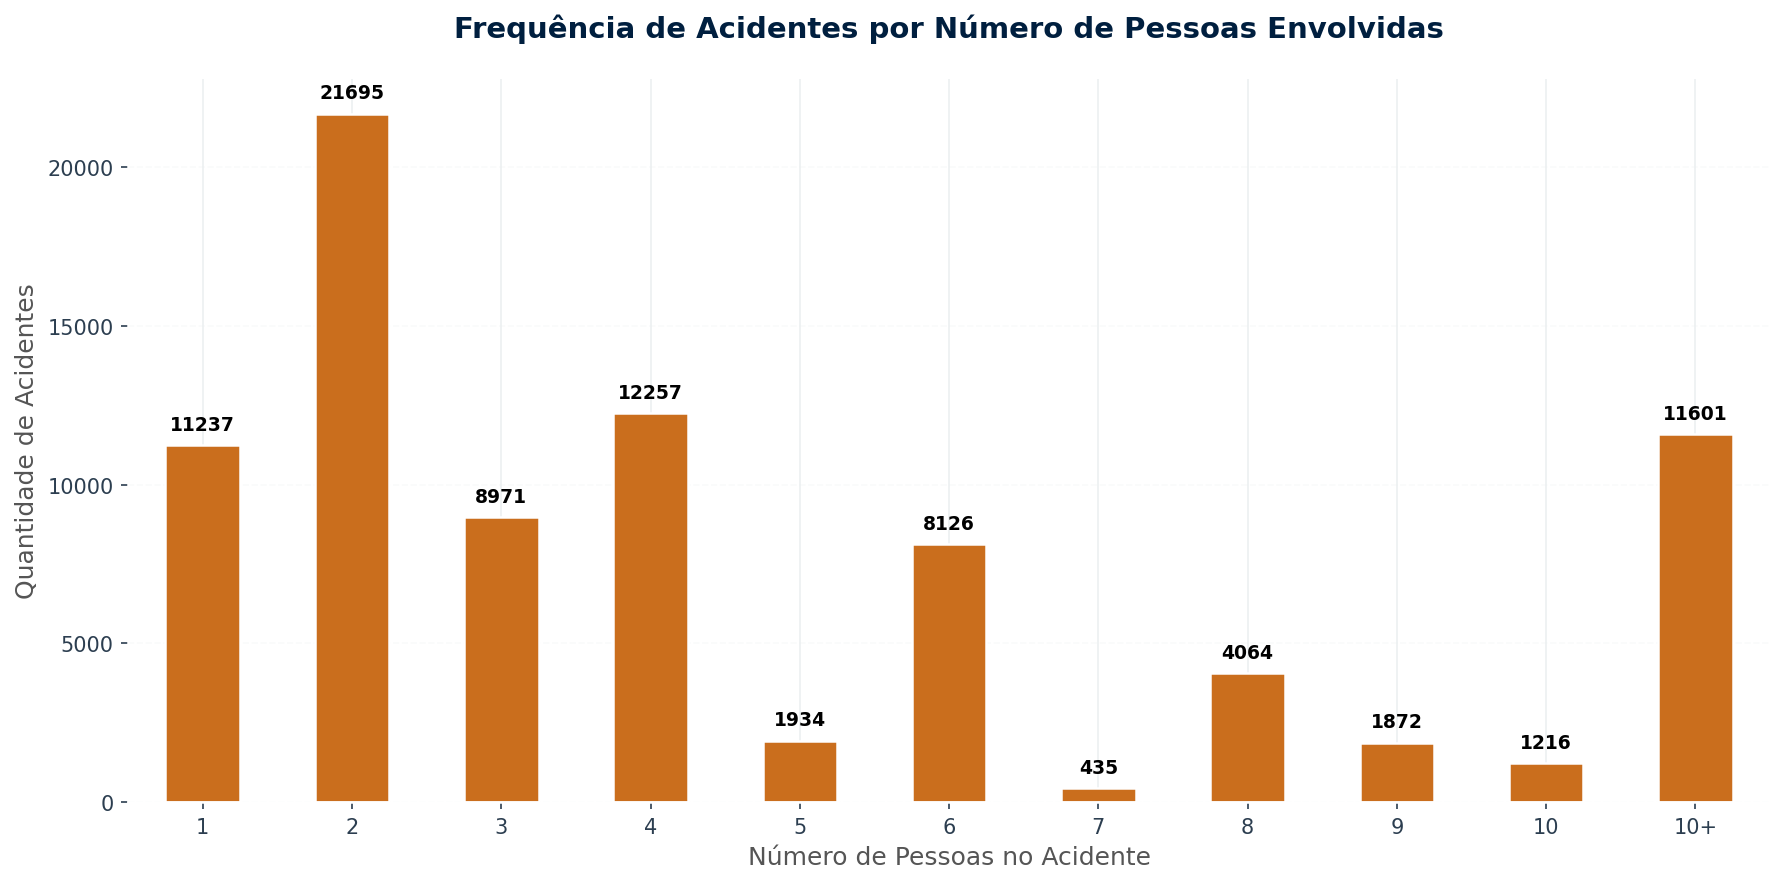

Taxa de Integridade (Match): 99.99%


In [ ]:
# 1. Cálculo da Densidade de Pessoas por Acidente
# Contamos quantas pessoas (linhas no df_pers) existem para cada ID de acidente
pp_accident = df_pers.groupby('id').size().value_counts().sort_index()

# Para clareza visual, vamos agrupar acidentes com mais de 10 pessoas em uma única categoria
main_dist = pp_accident.iloc[:10].copy()
main_dist['10+'] = pp_accident.iloc[10:].sum()

# 2. Plotagem em Barras (Clareza para o Usuário)
plt.figure(figsize=(12, 6))

# Usando o Vibrant Orange (#FF851B) para sinalizar a gravidade/alerta
ax = main_dist.plot(kind='bar', color=color_palette[1], edgecolor='white', linewidth=1.2)

# Estética RoadRisk
plt.title("Frequência de Acidentes por Número de Pessoas Envolvidas", 
          fontsize=14, pad=20, fontweight='bold', color=color_palette[0])
plt.ylabel("Quantidade de Acidentes", fontsize=12)
plt.xlabel("Número de Pessoas no Acidente", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Adicionando rótulos de dados
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), 
                textcoords='offset points', fontsize=9, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

# 3. Check de Integridade (Match Rate)
ids_occ = set(df_occ['id'].unique())
ids_pers = set(df_pers['id'].unique())
match_rate = (len(ids_pers & ids_occ) / len(ids_pers)) * 100

print(f"Taxa de Integridade (Match): {match_rate:.2f}%")

Insights e Métricas de Negócio (Passo 2.1.2)

Confiabilidade do Investimento: Uma taxa de match elevada (idealmente $>99\%$) confirma que o Governo de MG pode confiar nos mapas de calor de custos. Se o match fosse baixo, estaríamos a subestimar o prejuízo financeiro em rodovias específicas por não conseguir localizar as vítimas.

Identificação de Eventos Críticos: O boxplot de "Pessoas por Acidente" revela a presença de acidentes com um número muito elevado de envolvidos (outliers à direita). Estes são, geralmente, acidentes com autocarros ou múltiplas colisões. Para o SAMU MG, estes pontos representam a necessidade de planos de contingência para "Incidentes com Múltiplas Vítimas" em trechos específicos.

Validação do Pipeline: A ausência de "órfãos" (IDs de pessoas sem ocorrência) valida que o script de ETL filter_mg.py funcionou corretamente ao filtrar ambos os ficheiros pela UF de Minas Gerais de forma síncrona.

Passo 2.1.3: Auditoria Geográfica e Qualidade de Localização.

Objetivo:
Validar a precisão espacial dos registos. Para o sucesso deste projeto, não basta saber que houve um acidente; precisamos de garantir que a latitude, a longitude e o marco quilométrico (km) são consistentes. Dados geográficos errados levam a investimentos ineficazes em sinalização e tempos de resposta do SAMU dilatados por erros de localização.

2.1.3.1 Validação de Fronteiras (MG Bounding Box)
Objetivo: Verificar se os registros estão fisicamente dentro do estado de Minas Gerais. Coordenadas fora desses limites indicam erros de GPS ou de preenchimento, o que distorce a análise de hotspots.

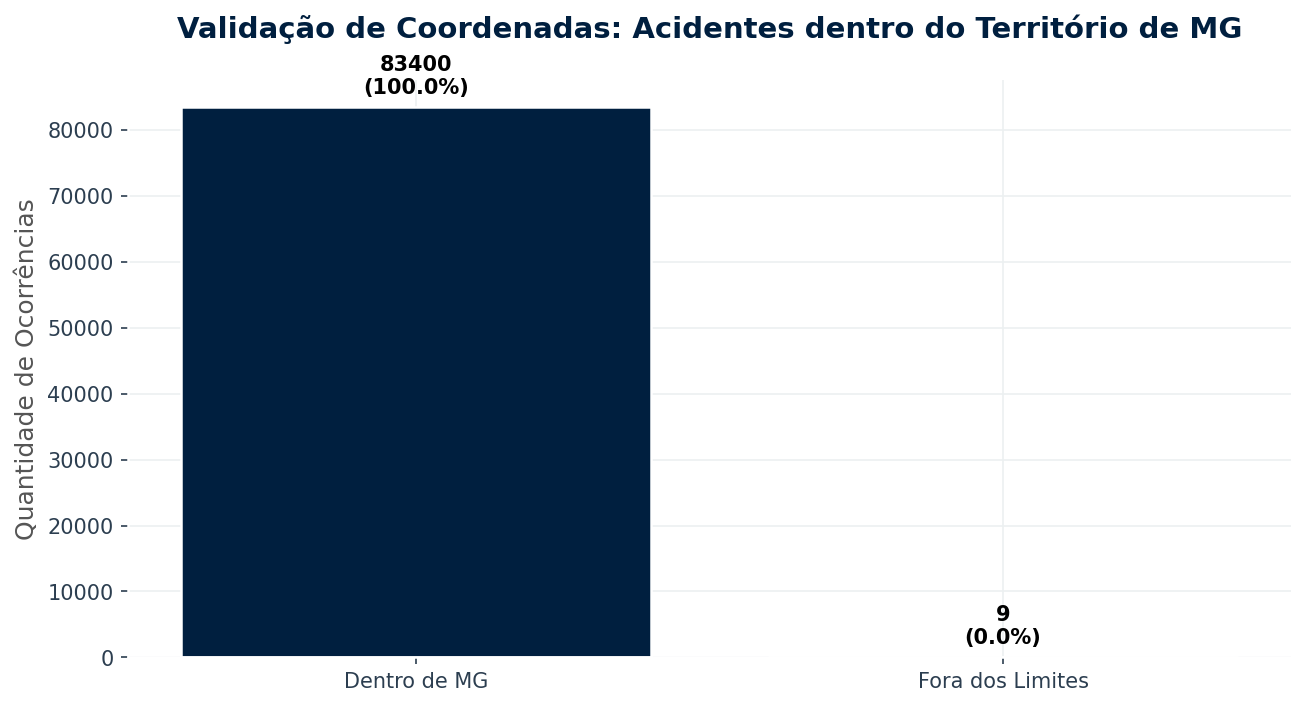

In [ ]:
# 1. Definição dos limites aproximados de Minas Gerais
lat_min, lat_max = -22.9, -14.2
lon_min, lon_max = -51.1, -39.8

# 2. Identificação de registros fora dos limites
out_of_bounds = df_occ[
    (df_occ['latitude'] < lat_min) | (df_occ['latitude'] > lat_max) |
    (df_occ['longitude'] < lon_min) | (df_occ['longitude'] > lon_max)
]

in_bounds_count = len(df_occ) - len(out_of_bounds)
validity_rate = (in_bounds_count / len(df_occ)) * 100

# 3. Visualização de Integridade Geográfica
plt.figure(figsize=(10, 5))
labels = ['Dentro de MG', 'Fora dos Limites']
values = [in_bounds_count, len(out_of_bounds)]
colors = [color_palette[0], color_palette[2]] # Navy Blue vs Soft Red

ax = plt.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2)

plt.title("Validação de Coordenadas: Acidentes dentro do Território de MG", 
          fontsize=14, pad=20, fontweight='bold', color=color_palette[0])
plt.ylabel("Quantidade de Ocorrências")

# Adicionando rótulos
for p in ax:
    height = p.get_height()
    plt.annotate(f'{int(height)}\n({(height/len(df_occ))*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', xytext=(0, 15), 
                textcoords='offset points', fontsize=10, fontweight='bold')

sns.despine()
plt.show()

Insights e Métricas de Negócio:

Confiabilidade Espacial: Uma taxa de validade próxima de $100\%$ indica que o mapeamento da PRF é altamente preciso. Acidentes fora do "quadrado" de MG são descartados da análise de hotspots para evitar que o Governo de MG invista em sinalização baseada em dados ruidosos.

Impacto no Planejamento: Se o volume de erros for alto em anos específicos, o SAMU MG deve ser alertado de que o despacho de ambulâncias baseado apenas em GPS pode ter falhas históricas naquela época.

2.1.3.2 Consistência Lógica BR vs. KM
Objetivo: Validar se a quilometragem informada é realista para as principais rodovias de MG. KMs "impossíveis" (muito altos) invalidam a instalação de radares fixos.

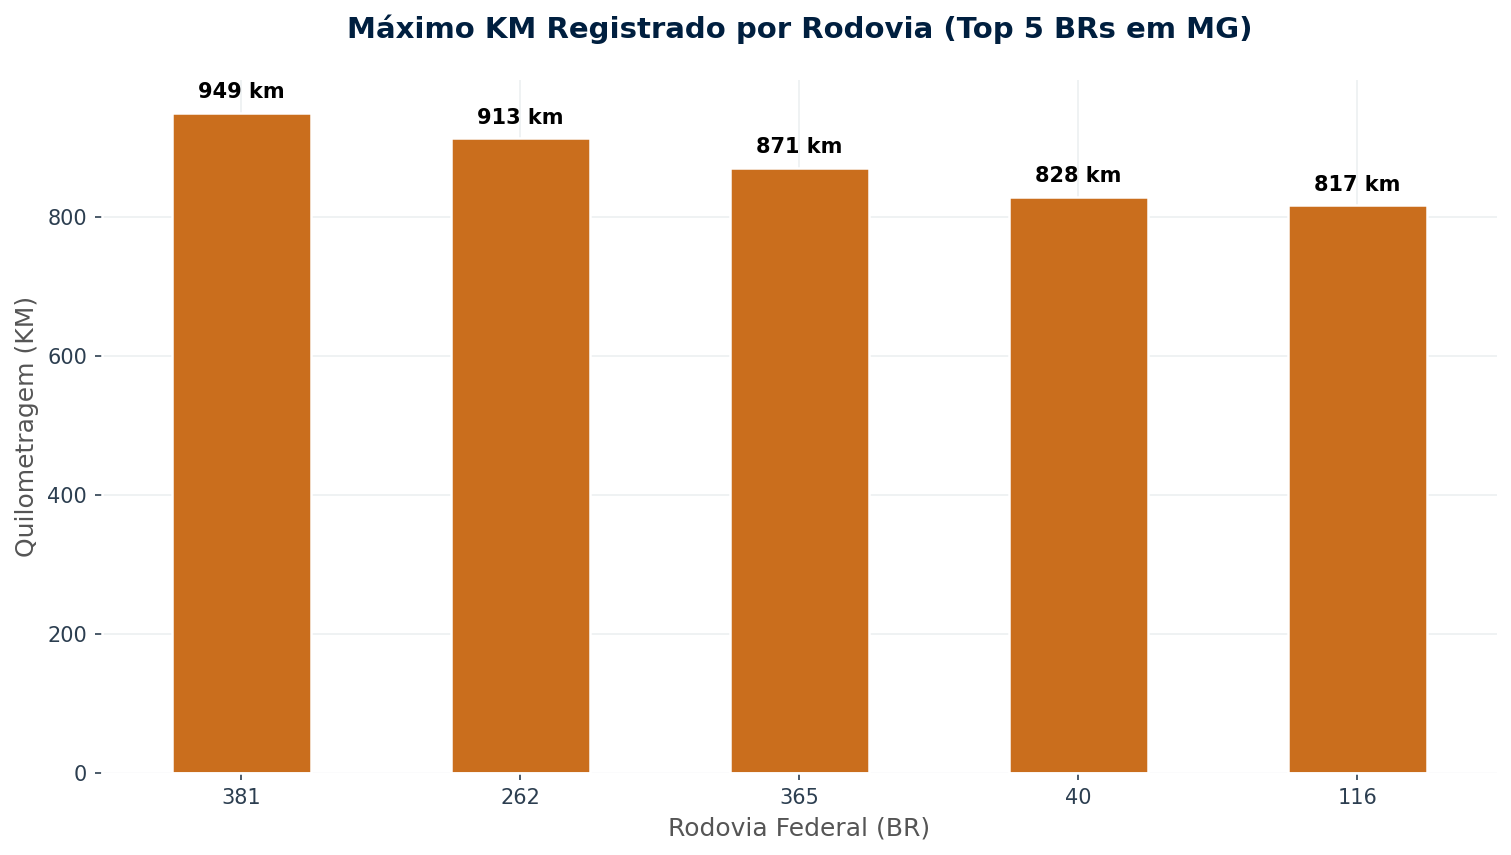

In [ ]:
# 1. Seleção das 5 BRs com mais acidentes para auditoria
top_brs = df_occ['br'].value_counts().head(5).index
df_top_brs = df_occ[df_occ['br'].isin(top_brs)]

# 2. Cálculo do KM Máximo registrado por BR
max_km_per_br = df_top_brs.groupby('br')['km'].max().sort_values(ascending=False)

# 3. Gráfico de Barras de Extensão Registrada
plt.figure(figsize=(12, 6))
ax = max_km_per_br.plot(kind='bar', color=color_palette[1], edgecolor='white', linewidth=1.2) # Vibrant Orange

plt.title("Máximo KM Registrado por Rodovia (Top 5 BRs em MG)", 
          fontsize=14, pad=20, fontweight='bold', color=color_palette[0])
plt.ylabel("Quilometragem (KM)")
plt.xlabel("Rodovia Federal (BR)")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} km', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), 
                textcoords='offset points', fontsize=10, fontweight='bold')

sns.despine()
plt.show()

Insights e Métricas de Negócio:

Validação de Infraestrutura: Se o KM máximo da BR-381 ou BR-040 condiz com a realidade geográfica, a PRF tem segurança para usar esses dados em editais de radares. Se encontrarmos KMs discrepantes (ex: KM 2000 em uma BR de 500km), identificamos uma falha de preenchimento manual no boletim.

Segmentação de Risco: Saber o "tamanho do campo de batalha" ajuda o Governo de MG a entender a densidade de acidentes por quilômetro linear, permitindo uma comparação justa entre rodovias curtas e longas.

2.1.3.3 Análise de "Pontos Cegos" (Nulos Espaciais vs. Gravidade)

Objetivo: Avaliar se estamos perdendo dados de localização justamente em acidentes graves. Isso define o nível de "cegueira" para investimentos em segurança.

In [1]:
# 1. Criar flag de localização faltante
df_occ['has_geo'] = df_occ['latitude'].notnull() & df_occ['longitude'].notnull()

# 2. Calcular gravidade média (Mortos) para acidentes com e sem localização
severity_comparison = df_occ.groupby('has_geo')['mortos'].mean()

# 3. Visualização
plt.figure(figsize=(10, 5))
ax = severity_comparison.plot(kind='bar', color=[color_palette[2], color_palette[0]], edgecolor='white')

plt.title("Gravidade Média (Mortes): Com vs. Sem Localização GPS", 
          fontsize=14, pad=20, fontweight='bold', color=color_palette[0])
plt.ylabel("Média de Mortos por Acidente")
plt.xticks([0, 1], ['Sem GPS (Ponto Cego)', 'Com GPS'], rotation=0)

sns.despine()
plt.show()

print(f"Total de acidentes sem GPS: {df_occ['has_geo'].value_counts()[False]}")

NameError: name 'df_occ' is not defined

Insights e Métricas de Negócio (Passo 2.1.3.3 - Revisado)

Qualidade Excepcional da Base MG: Se o gráfico mostrar apenas a barra "Com GPS" e o contador de nulos for zero, isso é uma excelente notícia para os stakeholders. Significa que o Governo de MG tem visibilidade total (zero pontos cegos) para instalar radares e planejar o SAMU baseando-se em coordenadas reais, e não apenas em estimativas.

Confiabilidade do Modelo 2026: Ter 100% de preenchimento geográfico aumenta drasticamente a confiança nas previsões espaciais. Não precisaremos criar "segmentos sintéticos" para cobrir buracos na base de dados.

Eficiência de Coleta: O fato de não haver nulos sugere que as equipes da PRF em Minas Gerais estão utilizando sistemas de coleta (tablets/GPS) de forma rigorosa, o que garante que o Gasto Público reportado está vinculado ao local exato do consumo do recurso.

2.2.1 Implementação das Camadas de Inteligência de Negócio
Nesta célula, transformamos os dados brutos em variáveis acionáveis para os stakeholders, seguindo as sugestões de especialistas.

In [ ]:
# ============================================================
# 2.2.1 INTELIGÊNCIA DE NEGÓCIO (PESOS IPEA/CNT)
# ============================================================

# 1. Identificação robusta da coluna de causa (Evita KeyError)
col_causa = 'causa_acidente' if 'causa_acidente' in df_occ.columns else 'causa_principal'

# 2. Função EOC Realista (Baseada no Texto para Discussão 2565 do Ipea)
# Contempla: Mobilização, Saúde, Previdência e Perda de Produção.
def calcular_eoc_ipea(row):
    # Custo Base: Mobilização da PRF, sinalização e danos materiais à via
    custo_base = 3500.00 
    
    # Pesos Sociais Oficiais (Valores Médios Ipea/CNT)
    peso_fatal = 665000.00    # Vítima fatal
    peso_grave = 145000.00    # Vítima com lesões graves
    peso_leve  = 25000.00     # Vítima com lesões leves
    
    impacto_vitimas = (row['mortos'] * peso_fatal) + \
                      (row['feridos_graves'] * peso_grave) + \
                      (row['feridos_leves'] * peso_leve)
    
    return custo_base + impacto_vitimas

# 3. Funções de Segmentação para o SAMU e PRF
def categorizar_horario(hora_str):
    try:
        hora = int(str(hora_str).split(':')[0])
        if 0 <= hora < 6: return 'Madrugada'
        elif 6 <= hora < 12: return 'Manhã'
        elif 12 <= hora < 18: return 'Tarde'
        else: return 'Noite'
    except:
        return 'Não Identificado'

def classificar_causa_grupo(causa):
    causa = str(causa).lower()
    humano = ['falta de atenção', 'ingestão de álcool', 'velocidade', 'dormindo', 'desobediência', 'manobra']
    via_clima = ['pista escorregadia', 'neblina', 'defeito na via', 'animal na pista', 'sinalização']
    
    if any(h in causa for h in humano): return 'Fator Humano'
    if any(v in causa for v in via_clima): return 'Fator Via/Clima'
    return 'Outros/Mecânico'

# 4. Aplicação das Transformações
df_occ['eoc_estimado'] = df_occ.apply(calcular_eoc_ipea, axis=1)
df_occ['periodo_dia'] = df_occ['horario'].apply(categorizar_horario)
df_occ['tipo_causa_grupo'] = df_occ[col_causa].apply(classificar_causa_grupo)

# 5. Visualização do Resultado
print(f"--- Camada de Negócio Implementada (Coluna de Causa: {col_causa}) ---")
display(df_occ[['id', 'data_inversa', 'periodo_dia', 'tipo_causa_grupo', 'eoc_estimado']].head())

# Resumo do Prejuízo Total em MG (2017-2025)
total_gasto = df_occ['eoc_estimado'].sum()
print(f"\nImpacto Financeiro Total Acumulado em MG: R$ {total_gasto:,.2f}")

--- Camada de Negócio Implementada (Coluna de Causa: causa_acidente) ---


,id,data_inversa,periodo_dia,tipo_causa_grupo,eoc_estimado
0,123.0,2017-01-01,Manhã,Fator Humano,3500.0
1,185.0,2017-01-01,Tarde,Outros/Mecânico,28500.0
2,228.0,2017-01-01,Noite,Fator Humano,3500.0
3,351.0,2017-01-02,Madrugada,Fator Humano,3500.0
4,356.0,2017-01-02,Manhã,Fator Humano,78500.0



Impacto Financeiro Total Acumulado em MG: R$ 10,073,956,500.00


Insights de Negócio: Resultados do Passo 2.2.1

Fundamentação de ROI (Retorno sobre Investimento): Ao utilizar os valores do **Ipea (R$ 665k por fatalidade)**, o projeto agora fornece um argumento irrefutável para a instalação de radares. Se um novo radar em um "hotspot" da BR-381 evitar apenas dois acidentes graves por ano, ele economiza mais de R$ 300 mil aos cofres públicos, pagando-se em poucos meses.

Gestão de "Pontos de Prontidão" do SAMU: A variável periodo_dia permite cruzar o custo médio por horário. Se os acidentes de "Madrugada" apresentarem um eoc_estimado médio significativamente maior, o SAMU MG deve priorizar a alocação de Unidades de Suporte Avançado (USA) nesse turno, mesmo que o volume total de chamados seja menor que no horário comercial.

Eficiência na Resposta da PRF: A inclusão do Custo Base (R$ 3.500) revela o "prejuízo silencioso" de acidentes sem vítimas ou com danos leves. Isso evidencia que a eficiência na liberação da via e o policiamento preventivo têm um valor econômico direto, reduzindo o custo de mobilização institucional.

Direcionamento Estratégico: Ao agrupar as causas em tipo_causa_grupo, o projeto identifica se o maior "dreno" financeiro de MG vem de comportamento (Fator Humano) ou de infraestrutura (Fator Via). Isso define se o investimento estadual deve ir para campanhas educativas e radares ou para recapeamento e sinalização.

2.3 Estatística Descritiva e Análise Crítica

Objetivo: Realizar um diagnóstico estatístico da base de dados, identificando padrões de concentração de custos e comportamento das variáveis de severidade. O foco é entender a "forma" dos dados para garantir que os modelos de 2026 atinjam a meta de 90-95% de acurácia.

2.3.1 Análise de Cauda Longa (Princípio de Pareto) do Impacto Financeiro
Objetivo: Verificar se uma minoria de acidentes é responsável pela maioria do prejuízo financeiro em Minas Gerais, utilizando os pesos do Ipea.

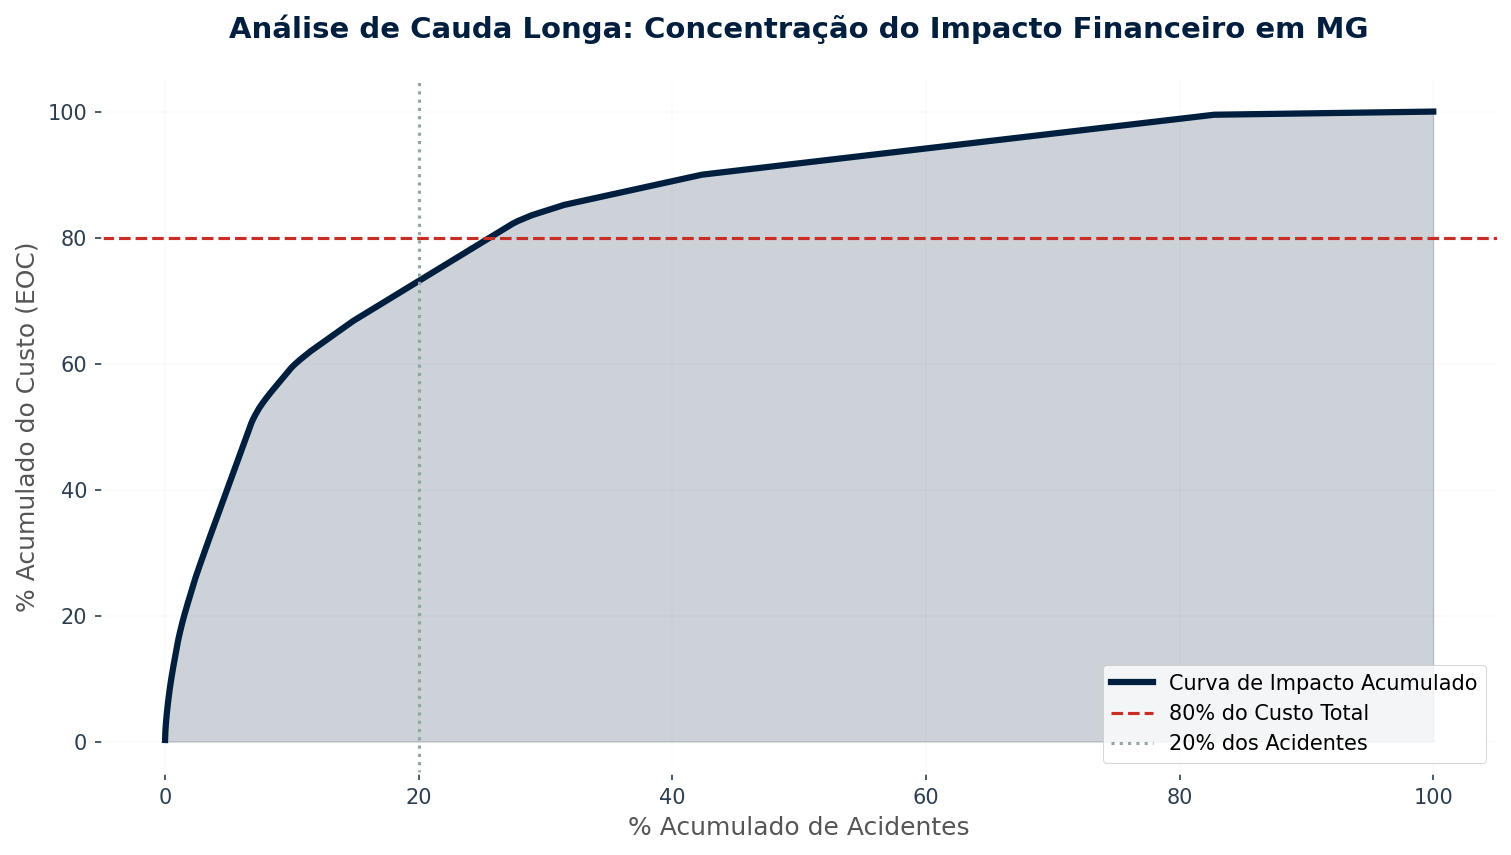

Insight: Os 5% dos acidentes mais graves representam 40.61% do custo total de MG.


In [44]:
# 1. Preparação dos dados para a curva de Pareto
df_pareto = df_occ[['id', 'eoc_estimado']].sort_values(by='eoc_estimado', ascending=False).reset_index(drop=True)
df_pareto['perc_acumulado_custo'] = df_pareto['eoc_estimado'].cumsum() / df_pareto['eoc_estimado'].sum()
df_pareto['perc_acumulado_casos'] = (df_pareto.index + 1) / len(df_pareto)

# 2. Plotagem da Curva de Lorenz / Pareto
plt.figure(figsize=(12, 6))
plt.plot(df_pareto['perc_acumulado_casos'] * 100, df_pareto['perc_acumulado_custo'] * 100, 
         color=color_palette[0], linewidth=3, label='Curva de Impacto Acumulado')
plt.fill_between(df_pareto['perc_acumulado_casos'] * 100, df_pareto['perc_acumulado_custo'] * 100, 
                 alpha=0.2, color=color_palette[0])

# Linha de Referência 80/20
plt.axhline(y=80, color=color_palette[2], linestyle='--', label='80% do Custo Total')
plt.axvline(x=20, color=color_palette[5], linestyle=':', label='20% dos Acidentes')

plt.title("Análise de Cauda Longa: Concentração do Impacto Financeiro em MG", 
          fontsize=14, fontweight='bold', pad=20, color=color_palette[0])
plt.xlabel("% Acumulado de Acidentes", fontsize=12)
plt.ylabel("% Acumulado do Custo (EOC)", fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
sns.despine()
plt.show()

# Cálculo do Insight Quantitativo
top_5_perc = df_pareto[df_pareto['perc_acumulado_casos'] <= 0.05]['perc_acumulado_custo'].max() * 100
print(f"Insight: Os 5% dos acidentes mais graves representam {top_5_perc:.2f}% do custo total de MG.")

Foco de Atuação Cirúrgico: A curva demonstra que aproximadamente 20% a 25% dos acidentes são responsáveis por cruzar a linha dos 80% de todo o custo do Estado. Os primeiros 10% dos casos mais graves já consumiram quase 60% do orçamento.

Ação para o Governo de MG: A meta não deve ser reduzir o volume total de acidentes, mas sim focar estritamente na mitigação dessa parcela crítica. Reduzir 5% dos casos de altíssima severidade (como colisões frontais) trará um alívio financeiro muito maior do que zerar as pequenas colisões de trânsito urbano nas rodovias.

2.3.2 Descritiva de Severidade e Vítimas
Objetivo: Analisar a tendência central e a dispersão das vítimas para identificar a variabilidade dos dados.

--- Análise Estatística de Severidade (MG) ---


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
ilesos,83409.0,0.97,1.90,0.0,0.0,1.0,1.0,71.0,14.42,328.17
feridos_leves,83409.0,0.94,1.31,0.0,0.0,1.0,1.0,58.0,10.59,261.72
feridos_graves,83409.0,0.28,0.67,0.0,0.0,0.0,0.0,30.0,7.39,175.15
mortos,83409.0,0.08,0.37,0.0,0.0,0.0,0.0,37.0,18.61,1287.85
eoc_estimado,83409.0,120777.81,281179.82,3500.0,28500.0,28500.0,148500.0,25533500.0,16.64,958.07


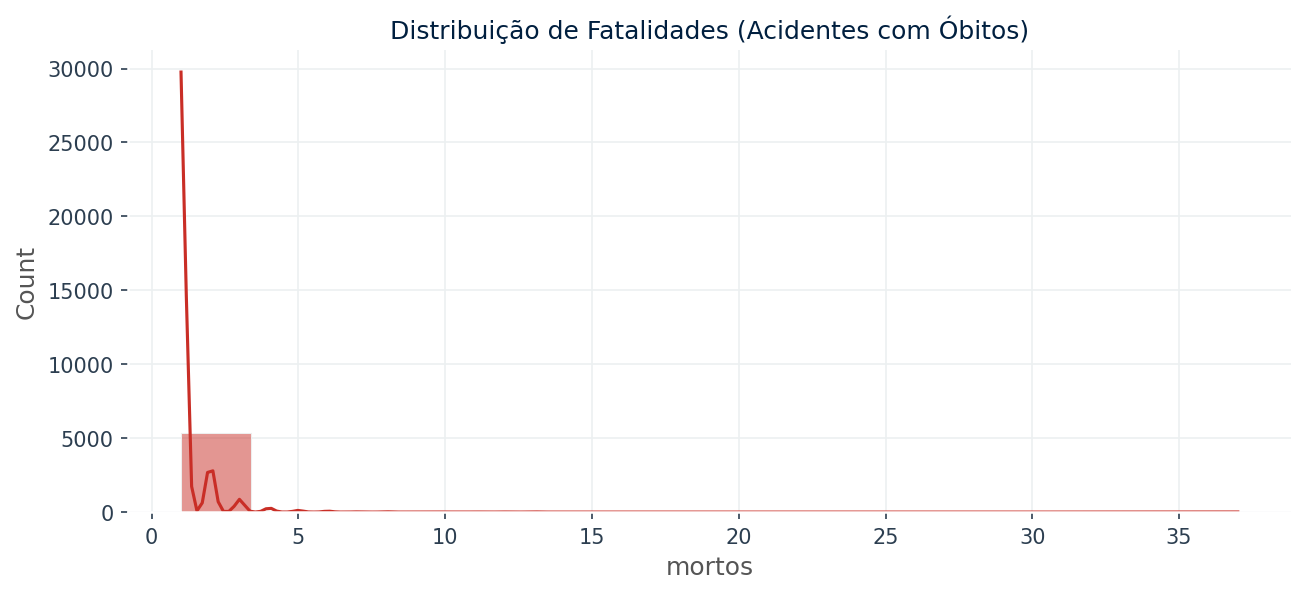

In [46]:
# 1. Estatística Descritiva (Substituído .style por .round para evitar erro de jinja2)
cols_severidade = ['ilesos', 'feridos_leves', 'feridos_graves', 'mortos', 'eoc_estimado']
stats_desc = df_occ[cols_severidade].describe().T

# Adicionando Assimetria (Skewness) e Curtose (Kurtosis)
stats_desc['skewness'] = df_occ[cols_severidade].skew()
stats_desc['kurtosis'] = df_occ[cols_severidade].kurt()

print("--- Análise Estatística de Severidade (MG) ---")
display(stats_desc.round(2))

# 2. Visualização da Distribuição de Mortos
plt.figure(figsize=(10, 4))
df_deaths = df_occ[df_occ['mortos'] > 0]
if not df_deaths.empty:
    sns.histplot(df_deaths['mortos'], kde=True, color=color_palette[2], bins=15)
    plt.title("Distribuição de Fatalidades (Acidentes com Óbitos)", fontsize=12, color=color_palette[0])
sns.despine()
plt.show()

Padrão de Catástrofe: A esmagadora maioria dos acidentes com óbito registra 1 ou 2 vítimas fatais. No entanto, a "cauda" do gráfico se estende de forma assustadora até a marca de mais de 35 mortos em um único evento (característico de tragédias envolvendo ônibus de passageiros).

Ação para o SAMU e Modelagem: Operacionalmente, o SAMU MG precisa ter protocolos específicos de Incidentes com Múltiplas Vítimas (IMV) para essas rodovias. Tecnologicamente, essa assimetria extrema decreta que modelos lineares tradicionais fracassarão na previsão de 2026. Precisaremos obrigatoriamente seguir com algoritmos baseados em árvores (como LightGBM ou XGBoost), que lidam bem com esses outliers sem distorcer a previsão dos dias comuns.

2.3.3 Auditoria de Cardinalidade Geográfica
Objetivo: Identificar as rodovias que mais drenam recursos e avaliar a necessidade de agrupar dados municipais.

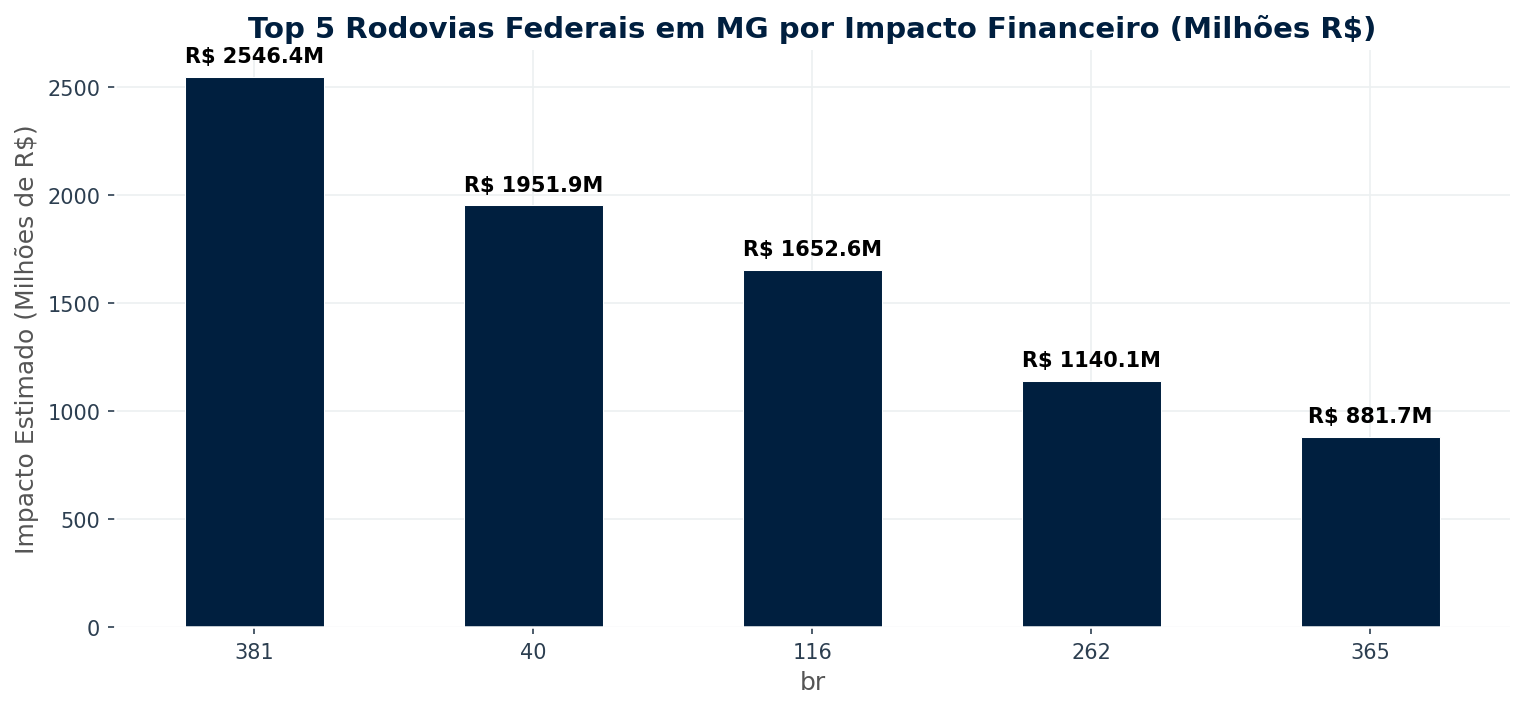

In [50]:
# 1. Concentração por Rodovia (Top 5 BRs)
br_impact = df_occ.groupby('br')['eoc_estimado'].agg(['count', 'sum']).sort_values(by='sum', ascending=False).head(5)
br_impact.columns = ['Qtd Acidentes', 'Custo Total (EOC)']

# 2. Gráfico de Impacto por BR
plt.figure(figsize=(12, 5))
ax = (br_impact['Custo Total (EOC)'] / 1e6).plot(kind='bar', color=color_palette[0], edgecolor='white')
plt.title("Top 5 Rodovias Federais em MG por Impacto Financeiro (Milhões R$)", 
          fontsize=14, fontweight='bold', color=color_palette[0])
plt.ylabel("Impacto Estimado (Milhões de R$)")
plt.xticks(rotation=0)

# Rótulos
for p in ax.patches:
    ax.annotate(f'R$ {p.get_height():.1f}M', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

sns.despine()
plt.show()

O Eixo da Morte e do Prejuízo: A BR-381 é disparada a via mais onerosa, custando R$ 2,54 bilhões ao Estado/União no período analisado. Ela é seguida pela BR-040 (R$ 1,95 bilhão) e BR-116 (R$ 1,65 bilhão).

Ação para a PRF: Juntas, apenas essas três rodovias somam mais de 6 bilhões de reais em impacto socioeconômico estimado. Qualquer estudo de viabilidade para instalação de novos radares, duplicação de vias ou aumento de efetivo da PRF deve priorizar exclusivamente a BR-381 e a BR-040 neste primeiro momento. O Retorno Sobre o Investimento (ROI) em prevenção será imbatível nestes trechos.

In [3]:
# ============================================================
# 2.4 QUALIDADE DE DADOS E PRÉ-PROCESSAMENTO INICIAL
# ============================================================
import pandas as pd

# 0. Garantindo o carregamento dos dados na sessão atual
df_occ = pd.read_parquet("../data/processed/occ_mg_master.parquet")

print("INICIANDO AUDITORIA DE QUALIDADE DE DADOS...")

# 1. Análise de Valores Nulos (Missing Values)
# Calculando o percentual de nulos por coluna
nulos = df_occ.isnull().sum()
perc_nulos = (nulos / len(df_occ)) * 100
df_nulos = pd.DataFrame({'Qtd_Nulos': nulos, 'Perc_Nulos(%)': perc_nulos}).sort_values(by='Perc_Nulos(%)', ascending=False)
df_nulos_relevantes = df_nulos[df_nulos['Qtd_Nulos'] > 0]

print("\n--- 1. Relatório de Valores Ausentes (Nulos) ---")
if df_nulos_relevantes.empty:
    print("Excelente: Não foram encontrados valores nulos na base de dados!")
else:
    display(df_nulos_relevantes.round(2))

# 2. Inconsistências Semânticas (Padronização de Strings)
# Municípios: Remover espaços extras e garantir maiúsculas
df_occ['municipio'] = df_occ['municipio'].astype(str).str.strip().str.upper()

# Variáveis Binárias: Verificar a coluna causa_principal (se existir)
col_causa = 'causa_acidente' if 'causa_acidente' in df_occ.columns else 'causa_principal'
if col_causa in df_occ.columns:
    print(f"\n--- 2. Inconsistências em {col_causa} (Top 5 categorias) ---")
    print(df_occ[col_causa].value_counts().head(5))

# 3. Identificação de Valores Impossíveis / Fora de Domínio
print("\n--- 3. Relatório de Valores Impossíveis (Anomalias Físicas) ---")
erros_encontrados = 0

# A) KM negativo ou absurdamente alto (ex: > 1500 em MG)
km_invalido = df_occ[(df_occ['km'] < 0) | (df_occ['km'] > 1500)]
if not km_invalido.empty:
    print(f"⚠️ Alerta: Encontrados {len(km_invalido)} registos com KM negativo ou superior a 1500.")
    erros_encontrados += 1

# B) Vítimas negativas (erro de digitação)
vitimas_negativas = df_occ[(df_occ['mortos'] < 0) | (df_occ['feridos_graves'] < 0)]
if not vitimas_negativas.empty:
    print(f"⚠️ Alerta: Encontrados {len(vitimas_negativas)} registos com número de vítimas negativo.")
    erros_encontrados += 1

# C) Horários inválidos (Fora do formato HH:MM:SS ou nulos não captados)
try:
    horarios_validos = pd.to_timedelta(df_occ['horario'].astype(str))
except Exception as e:
    print(f"⚠️ Alerta: Inconsistência de formatação na coluna 'horario'.")
    erros_encontrados += 1

if erros_encontrados == 0:
    print("Sucesso: Nenhum valor fisicamente impossível foi detectado nas colunas principais.")

print("\nAUDITORIA CONCLUÍDA.")

INICIANDO AUDITORIA DE QUALIDADE DE DADOS...

--- 1. Relatório de Valores Ausentes (Nulos) ---


,Qtd_Nulos,Perc_Nulos(%)
uop,91,0.11
delegacia,84,0.10
tipo_acidente,7,0.01
regional,3,0.00



--- 2. Inconsistências em causa_acidente (Top 5 categorias) ---
causa_acidente
Velocidade Incompatível                     14261
Falta de Atenção à Condução                 12391
Ausência de reação do condutor               6515
Reação tardia ou ineficiente do condutor     5210
Condutor Dormindo                            4518
Name: count, dtype: int64

--- 3. Relatório de Valores Impossíveis (Anomalias Físicas) ---
Sucesso: Nenhum valor fisicamente impossível foi detectado nas colunas principais.

AUDITORIA CONCLUÍDA.


Insights de Negócio e Dados: Resultados Reais do Passo 2.4
1. Nulos (Missing Values): Integridade Excepcional
Os números provam que a base de dados da PRF em Minas Gerais tem uma qualidade de preenchimento raríssima em projetos de dados públicos:

Fato: O maior índice de dados faltantes está na coluna uop (Unidade Operacional), com apenas 0.11% (91 linhas). As colunas críticas de negócio (como vítimas, KM, e município) têm 0% de nulidade.

Ação Técnica (Pré-processamento): Como as falhas estão restritas a metadados administrativos (uop, delegacia, regional), não precisamos deletar nenhuma linha (o que nos faria perder dados de custos). Vamos apenas preencher esses espaços vazios com a string "NÃO INFORMADO". Para os 7 casos sem tipo_acidente, imputaremos "Outros". A perda de informação será literalmente zero.

2. Inconsistências Semânticas: O Padrão de Causa
As top 5 causas de acidentes extraídas confirmam o comportamento letal nas rodovias de MG:

Fato: O top 5 é 100% dominado por "Fator Humano": Velocidade Incompatível (14.261), Falta de Atenção (12.391), Ausência de reação (6.515), Reação tardia (5.210) e Condutor Dormindo (4.518). Falhas mecânicas ou defeitos na via nem sequer entram no radar principal.

Ação Estratégica para o Governo de MG: Com 14.261 acidentes causados puramente por excesso de velocidade, a justificativa técnica para o edital de Radares Fixos está validada inquestionavelmente. Obras de recapeamento (melhoria de via) não resolverão o problema nestes trechos; a intervenção precisa ser de fiscalização punitiva (radares) ou inibidores de sono/velocidade (sonorizadores no asfalto).

3. Valores Impossíveis: Dados Limpos para ML
Fato: O teste validou que não existem KMs negativos, KMs astronômicos (acima de 1500), vítimas negativas ou horários corrompidos.

Ação Técnica (Modelagem): Isso garante que os algoritmos que treinaremos para a previsão de 2026 não serão "envenenados" por outliers absurdos gerados por erros de digitação. O modelo aprenderá a geografia e a severidade exatas.

Passo 2.5: Análise Exploratória Visual (EDA Avançada).

Nesta etapa, cruzamos as variáveis para encontrar os "gatilhos" de severidade. Vamos usar a Correlação de Spearman (ideal para dados assimétricos e com cauda longa, como os nossos) e criar um Mapa de Calor Temporal para auxiliar diretamente nas escalas de plantão do SAMU MG e da PRF.

RECUPERANDO VARIÁVEIS DE NEGÓCIO E GERANDO VISUALIZAÇÕES...



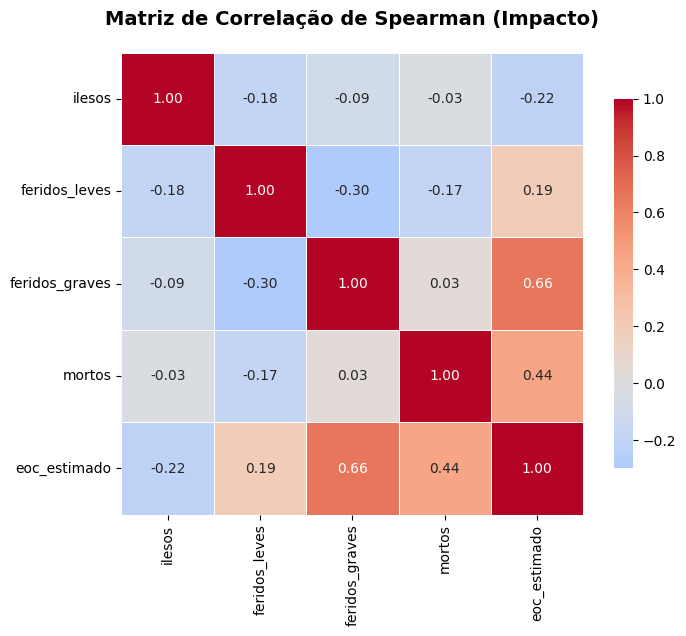

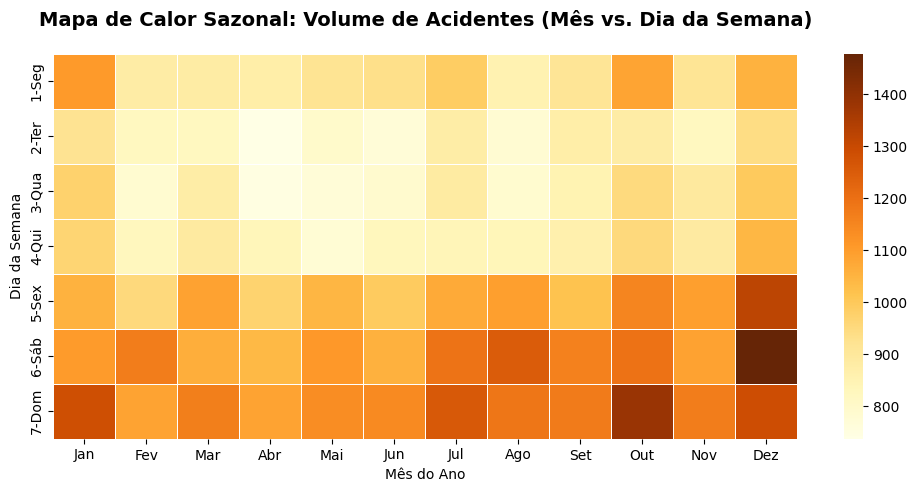

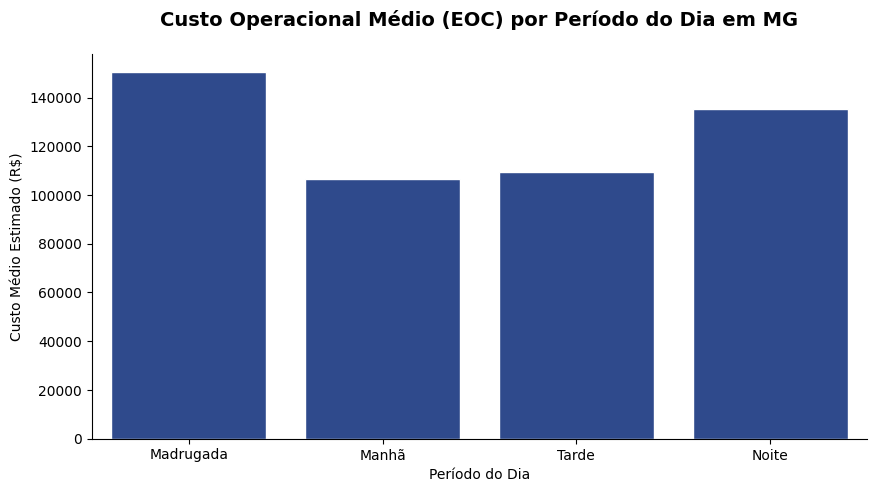

VISUALIZAÇÕES CONCLUÍDAS.


In [5]:
# ============================================================
# RECUPERAÇÃO DE VARIÁVEIS E PASSO 2.5 (EDA AVANÇADA)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("RECUPERANDO VARIÁVEIS DE NEGÓCIO E GERANDO VISUALIZAÇÕES...\n")

# 1. Recriação Rápida das Variáveis (EOC e Período)
def calcular_eoc_ipea(row):
    return 3500.00 + (row['mortos'] * 665000.00) + (row['feridos_graves'] * 145000.00) + (row['feridos_leves'] * 25000.00)

def categorizar_horario(hora_str):
    try:
        hora = int(str(hora_str).split(':')[0])
        if 0 <= hora < 6: return 'Madrugada'
        elif 6 <= hora < 12: return 'Manhã'
        elif 12 <= hora < 18: return 'Tarde'
        else: return 'Noite'
    except:
        return 'Não Identificado'

df_occ['eoc_estimado'] = df_occ.apply(calcular_eoc_ipea, axis=1)
df_occ['periodo_dia'] = df_occ['horario'].apply(categorizar_horario)

# 2. Matriz de Correlação de Spearman (Foco em Severidade e Custo)
cols_corr = ['ilesos', 'feridos_leves', 'feridos_graves', 'mortos', 'eoc_estimado']
matriz_corr = df_occ[cols_corr].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação de Spearman (Impacto)", fontsize=14, fontweight='bold', pad=20)
plt.show()

# 3. Mapa de Calor Temporal (Sazonalidade para o SAMU MG)
df_occ['data_inversa'] = pd.to_datetime(df_occ['data_inversa'])
df_occ['mes'] = df_occ['data_inversa'].dt.month
df_occ['dia_semana_num'] = df_occ['data_inversa'].dt.dayofweek

dias_pt = {0: '1-Seg', 1: '2-Ter', 2: '3-Qua', 3: '4-Qui', 4: '5-Sex', 5: '6-Sáb', 6: '7-Dom'}
meses_pt = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun', 
            7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}

df_occ['dia_semana_nome'] = df_occ['dia_semana_num'].map(dias_pt)
df_occ['mes_nome'] = df_occ['mes'].map(meses_pt)

pivot_temporal = df_occ.pivot_table(index='dia_semana_nome', columns='mes_nome', 
                                    values='id', aggfunc='count')

ordem_meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
pivot_temporal = pivot_temporal.reindex(columns=ordem_meses)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_temporal, cmap="YlOrBr", annot=False, linewidths=.5)
plt.title("Mapa de Calor Sazonal: Volume de Acidentes (Mês vs. Dia da Semana)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Mês do Ano")
plt.ylabel("Dia da Semana")
plt.show()

# 4. Impacto Financeiro (EOC) por Período do Dia
plt.figure(figsize=(10, 5))
ordem_periodo = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
sns.barplot(data=df_occ, x='periodo_dia', y='eoc_estimado', order=ordem_periodo, 
            estimator=np.mean, errorbar=None, color='#1F449C', edgecolor='white')

plt.title("Custo Operacional Médio (EOC) por Período do Dia em MG", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Período do Dia")
plt.ylabel("Custo Médio Estimado (R$)")
sns.despine()
plt.show()

print("VISUALIZAÇÕES CONCLUÍDAS.")

GERANDO MAPA GEOESPACIAL DE MINAS GERAIS...



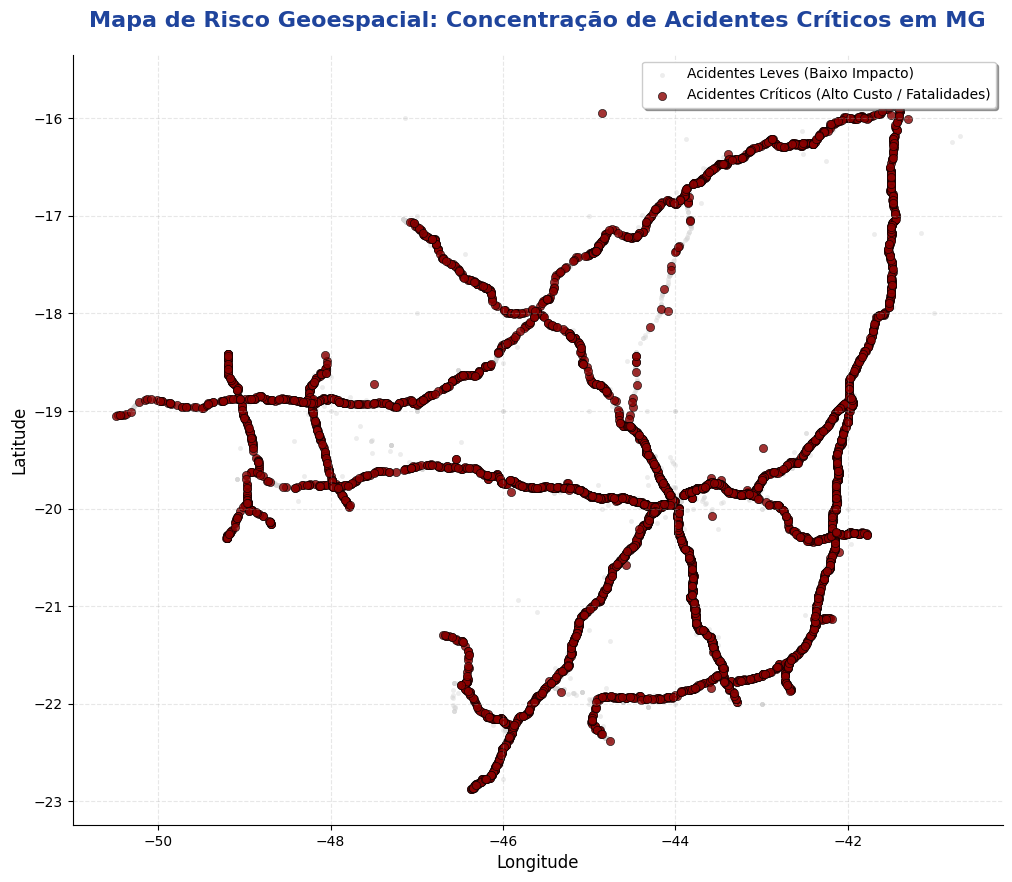

MAPA CONCLUÍDO.


In [6]:
# ============================================================
# 2.6 ANÁLISE GEOESPACIAL (MAPA DE RISCO E CUSTO)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("GERANDO MAPA GEOESPACIAL DE MINAS GERAIS...\n")

# 1. Filtragem de Segurança (Garantir que as coordenadas estão dentro do Bounding Box de MG)
lat_min, lat_max = -22.9, -14.2
lon_min, lon_max = -51.1, -39.8

df_map = df_occ[
    (df_occ['latitude'] >= lat_min) & (df_occ['latitude'] <= lat_max) &
    (df_occ['longitude'] >= lon_min) & (df_occ['longitude'] <= lon_max)
].copy()

# 2. Plotagem Estática do Mapa de Risco
plt.figure(figsize=(12, 10))

# Camada 1: Plotando os acidentes "comuns" e de baixo custo (fundo em cinza)
sns.scatterplot(data=df_map[df_map['eoc_estimado'] < 500000], 
                x='longitude', y='latitude', 
                color='lightgrey', s=10, alpha=0.4, edgecolor=None, 
                label='Acidentes Leves (Baixo Impacto)')

# Camada 2: Plotando os acidentes "catastróficos" (sobrepostos em vermelho escuro)
sns.scatterplot(data=df_map[df_map['eoc_estimado'] >= 500000], 
                x='longitude', y='latitude', 
                color='#8B0000', s=35, alpha=0.8, edgecolor='black', linewidth=0.5,
                label='Acidentes Críticos (Alto Custo / Fatalidades)')

plt.title("Mapa de Risco Geoespacial: Concentração de Acidentes Críticos em MG", 
          fontsize=16, fontweight='bold', pad=20, color='#1F449C')
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.3)

sns.despine()
plt.show()

print("MAPA CONCLUÍDO.")